In [25]:
# Configuração geral
CONFIG = {
    "img_size": 224,
    "batch_size": 32,
    # 50 epocas após melhoria de early stopping
    "epochs": 50,
    "lr": 1e-3,
    "dropout": 0.3,
    "weight_decay": 1e-4,    
    "num_workers": 2,
    "dataset_path": "/kaggle/input/datasets/awsaf49/coco-2017-dataset/coco2017",
    "num_classes": 2,
    "model_name": "comparison_cnn_vs_densenet"

}


In [26]:
# imports
import os, json, torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import transforms, models
# relatorio, matriz de confusao e visualização
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print('Device:', device)


Device: cuda


In [27]:
# Dataset (Base para CNN e DenseNet)
# Usada para cnn construida, densenet, treino e teste (nao muda entre os modelos)
class CocoBinaryDataset(Dataset):
    def __init__(self, image_dir, annotation_file, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        with open(annotation_file) as f:
            data = json.load(f)
        self.images = data['images']
        self.annotations = data['annotations']
        self.labels = {img['id']: 0 for img in self.images}
        for ann in self.annotations:
            if ann['category_id'] == 1:
                self.labels[ann['image_id']] = 1

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_info = self.images[idx]
        path = os.path.join(self.image_dir, img_info['file_name'])
        # contorno para crashes no kaggle relativos a imagem
        try:
            image = Image.open(path).convert('RGB')
        except:
            return self.__getitem__((idx + 1) % len(self.images))
        
        label = int(self.labels[img_info['id']])
        if self.transform:
            image = self.transform(image)
        return image, label

In [28]:
# Pré-processamento
# Todos os modelos usam. Serve para cnn construída, densenet , treino teste
# trasnform treino
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    # malhoria principal: data augmentation para que o modelo 'veja' imagens diferentes a cada época
    # invocando rotações, flips e algumas alterações de iluminação
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# transform validação/teste
val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [29]:
# Dataset + DataLoaders (Base do Experimento)
# Usada por cnn construída, densenet.
# dataset de treino
train_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/train2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_train2017.json",
    transform=train_transform
)

# Reduzindo o dataset de treino
# melhoria: garantindo que serão pegas as mesmas imagens
# garantindo resultados comparáveis entre cnn e a densenet
random.seed(42)
#.
train_indices = random.sample(range(len(train_dataset)), 5000)
train_dataset = Subset(train_dataset, train_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers']
)

# =========================
# dataset de validação/teste
# =========================
val_dataset = CocoBinaryDataset(
    image_dir=f"{CONFIG['dataset_path']}/val2017",
    annotation_file=f"{CONFIG['dataset_path']}/annotations/instances_val2017.json",
    transform=val_transform
)

# Reduzindo também o de teste/validação (pra a prova de conceito ficar rápida)
val_indices = random.sample(range(len(val_dataset)), 1000)
val_dataset = Subset(val_dataset, val_indices)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    # nao embaralhar no teste
    shuffle=False,  
    num_workers=CONFIG['num_workers']
)

# sanity check
view_sanity_check = False
if view_sanity_check:
    print(f"Treino: {len(train_dataset)} imagens")
    print(f"Teste: {len(val_dataset)} imagens")

In [30]:
# Criação da CNN da equipe 2
import torch.nn.functional as F

class cnn_equipe2(nn.Module):

    def __init__(self):
        super(cnn_equipe2, self).__init__()

        # blocos convolucionais
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # adaptive pooling
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4))

        # melhoria: regularização dropout
        # reduzindo o dropout de 0.5 para 0.3 ou até 0.2 na tentatiza de aumentar a accuracia 
        # depois de adicioanar batchnormalization
        self.dropout = nn.Dropout(CONFIG['dropout'])

        # Camadas densas
        self.fc1 = nn.Linear(128 * 4 * 4, 128)
        self.fc2 = nn.Linear(128, CONFIG['num_classes'])

    def forward(self, x):

        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = self.adaptive_pool(x)

        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))

        # melhoria: regularização com dropout
        x = self.dropout(x)

        x = self.fc2(x)

        return x


# Para a experiencia com transnfer learning e comparações
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
class cnn_equipe2_transfer_learning(nn.Module):
    def __init__(self):
        super(cnn_equipe2_transfer_learning, self).__init__()

        # carregar a DenseNet pré-treinada (ex: densenet121)
        self.features = models.densenet121(weights='IMAGENET1K_V1').features
        
        # congela os parâmetros (opcional, para usar como extrator fixo)
        # Isso impede que o backpropagation altere esses pesos iniciais.
        for param in self.features.parameters():
            param.requires_grad = False
            
        # identificar o número de características de entrada para a nova "cabeça"
        # na densenet121, a última camada de características tem 1024 neurônios.
        num_features = 1024 
        
        # cria a nova camada de classificação (Head)
        # substitui suas camadas fc1 e fc2 manuais
        self.classifier = nn.Sequential(
            # pooling global para reduzir dimensões
            nn.AdaptiveAvgPool2d((1, 1)), 
            nn.Flatten(),
            nn.Linear(num_features, 128),
            nn.ReLU(),
            # dropout de 0.2 é o mais indicado para a regularização e mitigação de overfitting
            # nn.Dropout(CONFIG['dropout']),
            nn.Dropout(0.2),
            nn.Linear(128, CONFIG['num_classes'])
        )
    
    def forward(self, x):
        # propaga a entrada pelas camadas convolucionais da DenseNet
        x = self.features(x)
        # passa pelo novo classificador (adaptado à identificação ou nao de pessoa na imagem)
        x = self.classifier(x)
        return x

# invocando o modelo
model_cnn = cnn_equipe2().to(device)


In [31]:
# Transfer Learning com Densenet
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
iniciar_ativacao_transfer_learning = False
if iniciar_ativacao_transfer_learning:
    model_dense = models.densenet121(pretrained=True)    
    # congelar as features
    for param in model_dense.features.parameters():
        param.requires_grad = False    
    # adaptar classificador (camada densa)
    model_dense.classifier = nn.Linear(
        model_dense.classifier.in_features,
        CONFIG['num_classes']
    )    
    model_dense = model_dense.to(device)

In [32]:
# Setup de treino
# Meta: suportar model_cnn (cnn da equipe 2) e model_dense
# Loss mesma para os dois modelos
criterion = nn.CrossEntropyLoss()
# Otimização
# CNN da equipe 2
# Melhoria: ajustes no learning rate da CNNEquipe2
# aumentadas as epocas de 25 para 50 apos melhoria de proteção de épocas early stopping
# melhoria: adicionado weight_decay que é uma regularização L2 de combate ao overfitting
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
# .
# DenseNet (só treina o classificador)
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
# optimizer_dense = optim.Adam(model_dense.classifier.parameters(), lr=CONFIG['lr'])

In [33]:
# Treinamento
# Função de treino reutilizável para model_cnn e model_dense
# Recap: model_cnn é a cnn da equipe 2 e model_dense é a densenet
# TODO: deslocar imports para o escopo
import matplotlib.pyplot as plt
import torch

# Essa função acompanha o histórico para plotagem de gráfico de treino
def train_model(model, optimizer, name="Model"):

    print(f"\nTreinando: {name}")

    # histórico para auxílio no acompanhamento das metricas
    train_loss_history = []
    val_loss_history = []
    train_acc_history = []
    val_acc_history = []
    # melhoria
    best_val_loss = float('inf')
    patience = 5
    counter = 0
    #.

    for epoch in range(CONFIG['epochs']):
        # treino
        model.train()
        
        total_loss = 0
        correct_train = 0
        total_train = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device).long()

            optimizer.zero_grad()
            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # usado para acuracia do treino
            _, predicted = torch.max(outputs, 1)

            total_train += labels.size(0)
            correct_train += (predicted == labels).sum().item()

        train_acc = correct_train / total_train
        train_loss = total_loss / len(train_loader)

        train_acc_history.append(train_acc)
        train_loss_history.append(train_loss)

        # validação/teste        
        model.eval()

        val_loss_total = 0

        correct_val = 0
        total_val = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(device)
                labels = labels.to(device).long()

                outputs = model(images)

                loss = criterion(outputs, labels)

                val_loss_total += loss.item()

                _, predicted = torch.max(outputs, 1)

                total_val += labels.size(0)
                correct_val += (predicted == labels).sum().item()

        val_acc = correct_val / total_val
        val_loss = val_loss_total / len(val_loader)

        val_acc_history.append(val_acc)
        val_loss_history.append(val_loss)
        # melhoria: early stopping
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            counter = 0
        else:
            counter += 1
            print(f"EarlyStopping counter: {counter}/{patience}")
            if counter >= patience:
                print(f"\nEarly stopping ativado na época {epoch+1}")
                break
        #.
        print(
            f"{name} | Epoch {epoch+1}/{CONFIG['epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_acc:.4f}"
        )

    # plotagem dos graficos de mátricas
    plt.figure(figsize=(12,5))

    # funcao de perda
    plt.subplot(1,2,1)

    plt.plot(train_loss_history, label='Train Loss')
    plt.plot(val_loss_history, label='Val Loss')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")

    plt.title(f"{name} - Loss")

    plt.legend()

    # acuracia
    plt.subplot(1,2,2)

    plt.plot(train_acc_history, label='Train Accuracy')
    plt.plot(val_acc_history, label='Val Accuracy')

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")

    plt.title(f"{name} - Accuracy")

    plt.legend()

    plt.show()

    return {
        "train_loss": train_loss_history,
        "val_loss": val_loss_history,
        "train_acc": train_acc_history,
        "val_acc": val_acc_history
    }


Treinando: CNNEquipe2
CNNEquipe2 | Epoch 1/50 | Train Loss: 0.6877 | Train Acc: 0.5458 | Val Loss: 0.6804 | Val Acc: 0.5770
CNNEquipe2 | Epoch 2/50 | Train Loss: 0.6734 | Train Acc: 0.5876 | Val Loss: 0.6729 | Val Acc: 0.6000
CNNEquipe2 | Epoch 3/50 | Train Loss: 0.6647 | Train Acc: 0.6048 | Val Loss: 0.6701 | Val Acc: 0.5710
CNNEquipe2 | Epoch 4/50 | Train Loss: 0.6601 | Train Acc: 0.6106 | Val Loss: 0.6575 | Val Acc: 0.6190
CNNEquipe2 | Epoch 5/50 | Train Loss: 0.6566 | Train Acc: 0.6170 | Val Loss: 0.6569 | Val Acc: 0.6140
EarlyStopping counter: 1/5
CNNEquipe2 | Epoch 6/50 | Train Loss: 0.6474 | Train Acc: 0.6232 | Val Loss: 0.6617 | Val Acc: 0.5960
EarlyStopping counter: 2/5
CNNEquipe2 | Epoch 7/50 | Train Loss: 0.6455 | Train Acc: 0.6336 | Val Loss: 0.6664 | Val Acc: 0.5830
CNNEquipe2 | Epoch 8/50 | Train Loss: 0.6493 | Train Acc: 0.6302 | Val Loss: 0.6463 | Val Acc: 0.6210
CNNEquipe2 | Epoch 9/50 | Train Loss: 0.6382 | Train Acc: 0.6326 | Val Loss: 0.6342 | Val Acc: 0.6610
CNNEq

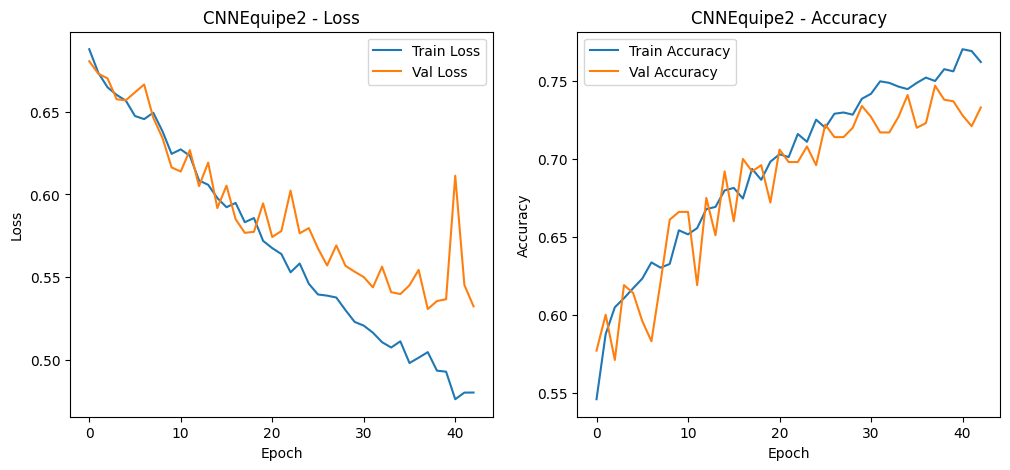

{'train_loss': [0.6877009701576962,
  0.6733711244194371,
  0.664697691893122,
  0.6600992839047863,
  0.6566223025701607,
  0.6473510098305477,
  0.6454884614914086,
  0.6493332454353381,
  0.6381996497986423,
  0.6244845656073017,
  0.6271882812688305,
  0.6233169128940363,
  0.6084155206847343,
  0.6057988936734048,
  0.5978066702936865,
  0.5922748845094329,
  0.5948517054888853,
  0.5832010807505079,
  0.5857119267913187,
  0.5719545136211784,
  0.5675476584464881,
  0.5639645540790194,
  0.552943609892183,
  0.5582604138714493,
  0.5460015315159111,
  0.5395484766003432,
  0.538852424188784,
  0.5377176629889543,
  0.5301379857549242,
  0.5230120006640246,
  0.5207384716553293,
  0.5164929148118207,
  0.5107412860272037,
  0.5075131614876401,
  0.5112570271750164,
  0.49815495074934263,
  0.5013590969477489,
  0.5047209539990516,
  0.4935477861932888,
  0.4929057463149356,
  0.47628028282693996,
  0.48028344485410457,
  0.4803148033512626],
 'val_loss': [0.6804280672222376,
  0.6

In [34]:
# Treinar os modelos
train_model(model_cnn, optimizer_cnn, name="CNNEquipe2")
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
#train_model(model_dense, optimizer_dense, name="DenseNet")

In [35]:
# Avaliação
def evaluate_model(model, name="Model"):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total

    print(f"\n{name} - Acurácia: {accuracy:.2f}%")
    print(classification_report(all_labels, all_preds))

    return accuracy, all_labels, all_preds

In [36]:
# Avaliação dos modelos
acc_cnn, labels_cnn, preds_cnn = evaluate_model(model_cnn, "CNNEquipe2")
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
#acc_dense, labels_dense, preds_dense = evaluate_model(model_dense, "DenseNet")


CNNEquipe2 - Acurácia: 73.30%
              precision    recall  f1-score   support

           0       0.67      0.82      0.74       464
           1       0.81      0.65      0.72       536

    accuracy                           0.73      1000
   macro avg       0.74      0.74      0.73      1000
weighted avg       0.75      0.73      0.73      1000



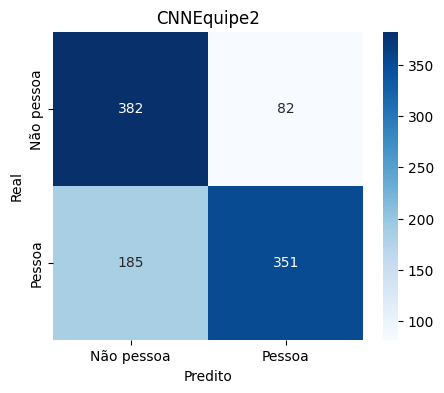

In [37]:
# matriz de confusao
def plot_confusion_matrix(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Não pessoa", "Pessoa"],
                yticklabels=["Não pessoa", "Pessoa"])
    
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.title(title)
    plt.show()


plot_confusion_matrix(labels_cnn, preds_cnn, "CNNEquipe2")
# TODO: Desativado durante o treino da cnn_equipe2 para atingir acurácia pŕoximo de 80%
# descomentar e rodar novamente após definição dos melhores parâmetros do dicionario CONFIG
#plot_confusion_matrix(labels_dense, preds_dense, "DenseNet")

In [38]:
# setup para visualizar as imagens por página
# de acordo com os modelos
import matplotlib.pyplot as plt
# hack:
# para nao ter que visualizar com as cores normalizadas com saturação de cor
def denormalize_hack(img):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    img = img.cpu().permute(1, 2, 0).numpy()
    img = std * img + mean
    img = np.clip(img, 0, 1)

    return img
# .
classes = ["Não pessoa", "Pessoa"]

def show_batch(images, labels, preds):
    plt.figure(figsize=(12, 6))

    for i in range(len(images)):
        # melhoria
        #img = images[i].cpu().permute(1, 2, 0).numpy()
        img = img = denormalize_hack(images[i])
        # .
        real = labels[i]
        prev = preds[i]

        if real == prev:
            color = "white"
            backgroundcolor = "green"
        else:
            color = "white"
            backgroundcolor = "red"

        title = f"Real: {classes[real]}\nPrev: {classes[prev]}"

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(title, fontsize=12, color=color, backgroundcolor=backgroundcolor)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


def visualize_model(model, name="Modelo"):
    print(f"\n🔍 Visualizando: {name}")
    
    model.eval()

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(test_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            print(f"Página {batch_idx + 1}")
            show_batch(images[:8], labels[:8], preds[:8])

            if batch_idx == 4:
                break

def visualizar(opcao=False):
    if opcao == 'modelo-equipe':
        visualize_model(model_cnn, "CNNEquipe2")
    if opcao == 'modelo-densenet':
        visualize_model(model_dense, "DenseNet")
    if not opcao:
        print("visualizar(opcao=['modelo-equipe' | 'desenet']")

In [39]:
# visualizar as imagens por página
# de acordo com os modelos
visualizar('modelo-equipe')


🔍 Visualizando: CNNEquipe2


NameError: name 'test_loader' is not defined